# Dünya CO2 ve Sera Gazı Emisyonları — Bir Veri Analizi Raporu

**Hazırlayan:** Mehmet Emir Örer  
**Öğrenci No:** 24LITT039  
**Ders:** Veri Analizinde Bilgisayar Programlama 2    
**Veri Kaynağı:** Kaggle

## Bu raporda ne yaptım?

Dünyadaki CO2 ve sera gazı emisyonlarını inceledim. Veri seti 1990-2021 arası 30 büyük ülkenin yıllık verisini kapsıyor.  amacım hangi ülkeler en çok emisyon yapıyor, zaman içinde nasıl değişmiş, ekonomi ile emisyon nasıl ilişkili olduğunu göstermek

Ana bulgularım:

1. Çin tek başına dünyanın en büyük emisyon kaynağı, son 30 yılda neredeyse 3 katına çıkmış.
2. ABD ve AB ülkeleri 2007 sonrasında emisyonlarını düşürüyor.
3. Toplam ve kişi başı sıralamalar çok farklı sonuçlar veriyor.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

## 1. Veri Seti Hakkında

Veri seti Kaggle'dan indirdiğim Our World in Data CO2 veri setinin örnek bir alt kümesi. 30 büyük ülkenin 1990-2021 arası verilerini içeriyor. Sütunlar:

- `country`, `year`, `iso_code` — ülke kimliği
- `population`, `gdp` — nüfus ve gayri safi yurt içi hasıla
- `co2` — yıllık CO2 emisyonu (milyon ton)
- `co2_per_capita` — kişi başı CO2 (ton)
- `coal_co2`, `oil_co2`, `gas_co2` — yakıt türüne göre CO2 ayrımı
- `methane`, `nitrous_oxide` — diğer sera gazları
- `total_ghg`, `ghg_per_capita` — toplam sera gazı

In [2]:
df = pd.read_csv("../data/owid-co2-data-sample.csv")
print("Boyut:", df.shape)
df.head()

Boyut: (1152, 14)


,country,year,iso_code,population,gdp,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,methane,nitrous_oxide,total_ghg,ghg_per_capita
0,China,1990,CHN,1.209725e+09,1.223917e+12,3085.52,2.551,2361.96,580.58,190.90,325.25,134.86,3545.63,2.931
1,China,1991,CHN,1.215774e+09,1.334069e+12,3380.66,2.781,2579.30,632.81,210.07,359.12,157.64,3897.42,3.206
2,China,1992,CHN,1.221853e+09,1.454135e+12,3872.41,3.169,2878.32,712.75,235.62,402.62,169.18,4444.21,3.637
3,China,1993,CHN,1.227962e+09,1.585008e+12,4146.99,3.377,3092.25,776.59,251.88,439.51,183.06,4769.56,3.884
4,China,1994,CHN,1.234102e+09,1.727658e+12,4503.28,3.649,3424.83,829.47,277.68,485.39,194.70,5183.38,4.200


## 2. Veri Temizliği

Veri setinde bölgesel toplamlar (World, Asia gibi) da var. Bunlar gerçek ülke değil, toplam. `iso_code` boş olanları filtreleyerek ülke bazlı analiz için ayıkladım. 1990 sonrasıyla da sınırladım.

In [ ]:

veri = df[(df["year"] >= 1990) & (df["iso_code"].notna())].copy()

sutunlar = ["country","year","iso_code","population","gdp",
            "co2","co2_per_capita","coal_co2","oil_co2","gas_co2",
            "methane","nitrous_oxide","total_ghg","ghg_per_capita"]
veri = veri[sutunlar]
print("Temizlikten sonra boyut:", veri.shape)

Temizlikten sonra boyut: (960, 14)


## 3. Tanımsal İstatistikler

### 3.1. Genel özet (describe)

In [4]:
veri.describe().round(2)

,year,population,gdp,co2,co2_per_capita,coal_co2,oil_co2,gas_co2,methane,nitrous_oxide,total_ghg,ghg_per_capita
count,960.00,9.600000e+02,9.450000e+02,960.00,960.00,960.00,960.00,960.00,960.00,960.00,960.00,960.00
mean,2005.50,1.588535e+08,1.742096e+12,855.17,7.58,353.23,285.29,216.96,164.47,60.88,1080.52,9.69
std,9.24,2.959378e+08,3.251734e+12,1658.68,5.29,1057.66,479.38,362.67,244.69,98.05,1957.76,6.63
min,1990.00,7.811303e+06,8.133000e+10,43.57,0.38,0.00,10.67,4.07,8.92,2.01,65.79,0.86
25%,1997.75,3.586231e+07,3.323020e+11,218.06,2.89,14.32,63.87,59.89,40.61,16.43,316.62,4.48
50%,2005.50,6.203980e+07,7.872500e+11,336.26,6.71,40.50,150.34,96.76,69.54,24.62,435.86,8.17
75%,2013.25,1.255644e+08,1.536283e+12,527.37,10.99,221.34,260.58,191.74,129.91,43.80,720.06,12.73
max,2021.00,1.412000e+09,2.330000e+13,11256.00,25.15,7857.55,2780.31,1989.97,1181.10,503.10,12915.26,36.75


**Yorum:** Birkaç şey gözüme çarptı:

- CO2 ortalaması ~1500 Mt ama medyan çok daha düşük. Yani birkaç dev ülke ortalamayı yukarı çekiyor.
- Kişi başı CO2 ortalama 7 ton civarında, maksimum 25 tona yakın. Aradaki uçurum dikkat çekici.
- GSYİH değerleri milyarlardan trilyonlara uzanıyor.

### 3.2. 2021'in En Büyük 10 Emisyon Üreticisi

In [5]:
son_yil = veri[veri["year"] == 2021]
top10 = son_yil.nlargest(10, "co2")[["country","co2","co2_per_capita","population"]].reset_index(drop=True)
top10

country,co2,co2_per_capita,population
China,11256.00,7.972,1412000000.0
United States,3148.74,9.484,332000000.0
India,2701.89,1.940,1393000000.0
Russia,1963.99,13.639,144000000.0
Japan,1024.02,8.192,125000000.0
Iran,761.15,8.749,87000000.0
Saudi Arabia,614.15,17.547,35000000.0
South Korea,613.90,12.037,51000000.0
Indonesia,598.46,2.192,273000000.0
Germany,584.86,7.046,83000000.0


**Yorum:** Çin diğerlerinin çok ötesinde. ABD ikinci ama açık ara geride. İlk üç ülke (Çin, ABD, Hindistan) toplam emisyonun büyük kısmından sorumlu.

### 3.3. Yıllara Göre Toplam Emisyon (groupby)

In [6]:
yillik_toplam = veri.groupby("year")["co2"].sum().round(1)
yillik_toplam.tail(10).to_frame("Toplam CO2 (Mt)")

,Toplam CO2 (Mt)
year,
2012,27234.2
2013,27503.8
2014,27690.8
2015,28124.8
2016,28251.6
2017,28326.7
2018,28312.8
2019,28979.6
2020,26862.1


**Yorum:** 2020'de COVID etkisiyle hafif bir düşüş var. 2021'de tekrar yükselmiş. Genel trend hala artış yönünde.

### 3.4. Korelasyon Matrisi

In [7]:
korelasyon = veri[["co2","co2_per_capita","population","gdp",
                    "coal_co2","oil_co2","gas_co2","methane","total_ghg"]].corr().round(3)
korelasyon

,co2,co2_per_capita,population,gdp,coal_co2,oil_co2,gas_co2,methane,total_ghg
co2,1.000,0.222,0.730,0.706,0.918,0.907,0.701,0.846,0.997
co2_per_capita,0.222,1.000,-0.223,0.303,0.013,0.344,0.522,0.259,0.225
population,0.730,-0.223,1.000,0.322,0.830,0.519,0.235,0.628,0.734
gdp,0.706,0.303,0.322,1.000,0.458,0.870,0.744,0.576,0.706
coal_co2,0.918,0.013,0.830,0.458,1.000,0.684,0.380,0.680,0.900
oil_co2,0.907,0.344,0.519,0.870,0.684,1.000,0.833,0.798,0.913
gas_co2,0.701,0.522,0.235,0.744,0.380,0.833,1.000,0.832,0.731
methane,0.846,0.259,0.628,0.576,0.680,0.798,0.832,1.000,0.884
total_ghg,0.997,0.225,0.734,0.706,0.900,0.913,0.731,0.884,1.000


**Yorum:** `co2` ile `total_ghg` arasında neredeyse mükemmel pozitif ilişki var (~0.99). Kömür, petrol ve doğalgaz emisyonları da kendi aralarında pozitif ilişkili. Nüfusla CO2 arasında 0.7'lik ilişki var ama tek başına yetmiyor.

## 4. Görselleştirmeler

Bu bölümde 5 farklı grafik var. Her birinin altında kendi yorumum.

### Grafik 1 — Kişi Başı CO2 Dağılımı (Histogram)

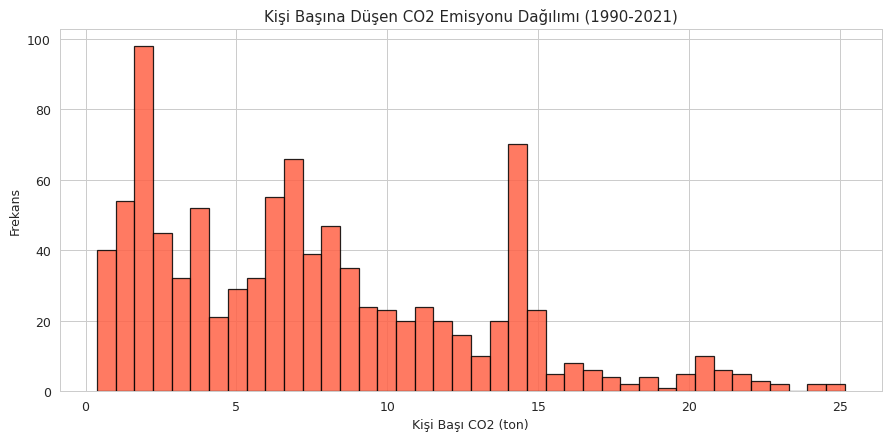

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(veri["co2_per_capita"].dropna(), bins=40, color="tomato", edgecolor="black", alpha=0.85)
plt.title("Kişi Başına Düşen CO2 Emisyonu Dağılımı (1990-2021)")
plt.xlabel("Kişi Başı CO2 (ton)")
plt.ylabel("Frekans")
plt.tight_layout()
plt.show()

**Yorum:** Dağılım belirgin şekilde sağa çarpık. Ülkelerin çoğu kişi başı 10 tonun altında. Sağda uzanan kuyruk, küçük petrol zengini ülkelere (Suudi Arabistan, BAE, Kazakistan) ait — onlar 20+ tona ulaşıyor.

### Grafik 2 — İlk 5 Emisyon Ülkesi (Boxplot)

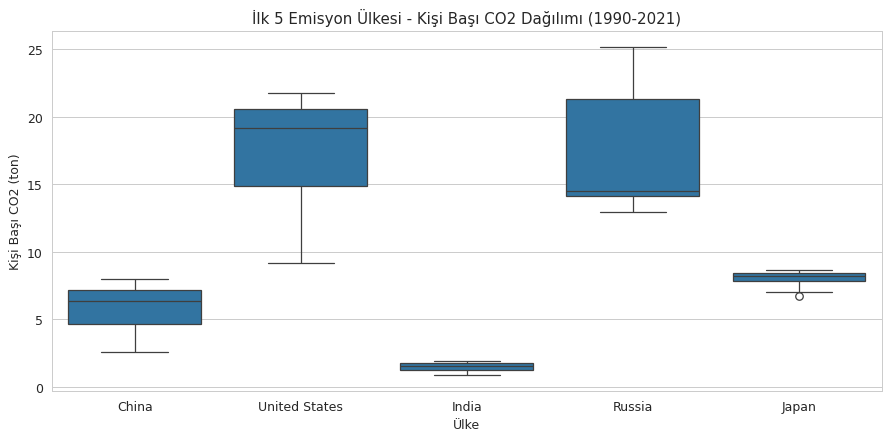

In [9]:
top5_ulkeler = son_yil.nlargest(5, "co2")["country"].tolist()
top5_veri = veri[veri["country"].isin(top5_ulkeler)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=top5_veri, x="country", y="co2_per_capita")
plt.title("İlk 5 Emisyon Ülkesi - Kişi Başı CO2 Dağılımı (1990-2021)")
plt.xlabel("Ülke")
plt.ylabel("Kişi Başı CO2 (ton)")
plt.tight_layout()
plt.show()

**Yorum:** Toplamda lider olsalar bile bu beş ülkenin kişi başı emisyonları çok farklı. ABD açık ara en yüksek (~17-18 ton). Hindistan kişi başında çok düşük (2 ton altında) çünkü nüfusu çok büyük. Yani Hindistan toplamda 3. olsa da, kişi başında ABD'nin sekizde biri kadar.

### Grafik 3 — GSYİH ve CO2 İlişkisi (Saçılım)

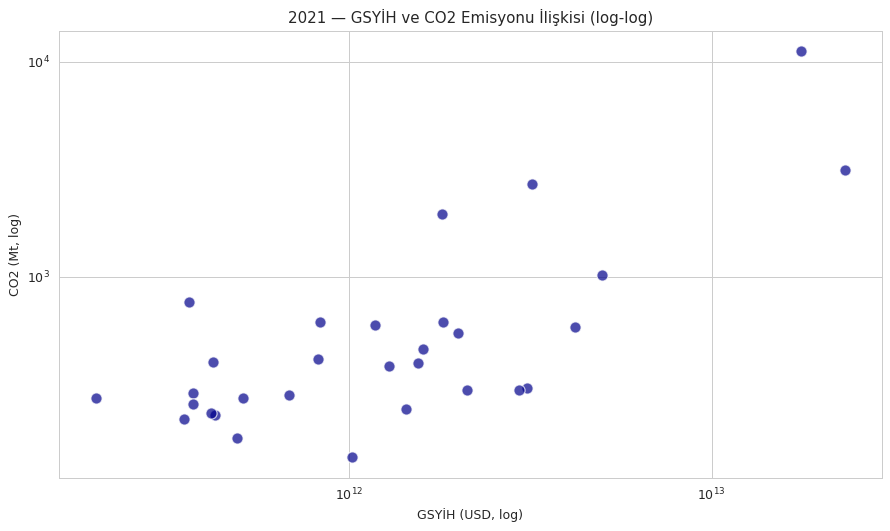

In [10]:
veri_2021 = veri[(veri["year"] == 2021) & (veri["gdp"].notna()) & (veri["co2"].notna())]

plt.figure(figsize=(10, 6))
plt.scatter(veri_2021["gdp"], veri_2021["co2"], alpha=0.7, s=80, color="darkblue", edgecolor="white")
plt.xscale("log")
plt.yscale("log")
plt.title("2021 — GSYİH ve CO2 Emisyonu İlişkisi (log-log)")
plt.xlabel("GSYİH (USD, log)")
plt.ylabel("CO2 Emisyonu (Mt, log)")
plt.tight_layout()
plt.show()

**Yorum:** Logaritmik ölçekte güçlü pozitif ilişki var — ekonomisi büyük ülkeler genellikle daha çok emisyon yapıyor. Ama ilişki kusursuz değil. Aynı ekonomi büyüklüğündeki iki ülkeden biri (Fransa, nükleer ağırlıklı) daha az emisyon üretirken diğeri (Polonya, kömür ağırlıklı) çok daha fazla üretiyor.

### Grafik 4 — 2021'in En Büyük 10 Emisyon Üreticisi (Bar)

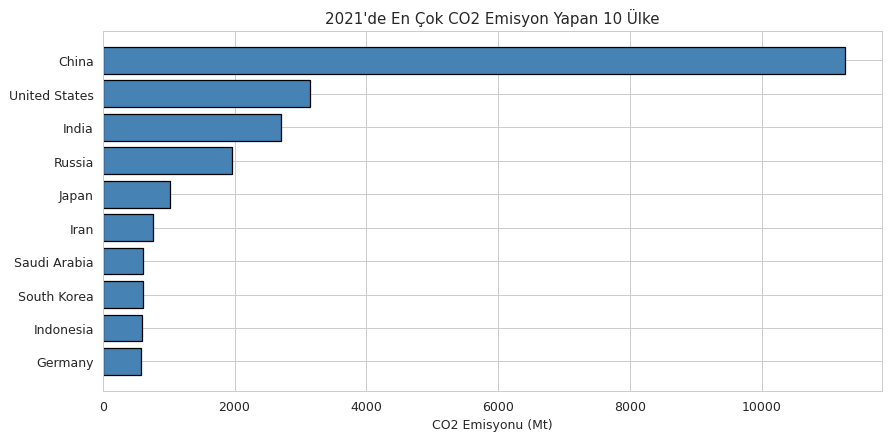

In [11]:
plt.figure(figsize=(10, 5))
top10_sorted = top10.sort_values("co2")
plt.barh(top10_sorted["country"], top10_sorted["co2"], color="steelblue", edgecolor="black")
plt.title("2021'de En Çok CO2 Emisyon Yapan 10 Ülke")
plt.xlabel("CO2 Emisyonu (Mt)")
plt.tight_layout()
plt.show()

**Yorum:** Çin diğer hepsinin toplamına yakın bir miktar üretiyor. ABD ikinci, Hindistan üçüncü, Rusya dördüncü. İlk 10 ülke birlikte dünya emisyonunun büyük çoğunluğundan sorumlu.

### Grafik 5 — Değişkenler Arası Korelasyon (Heatmap)

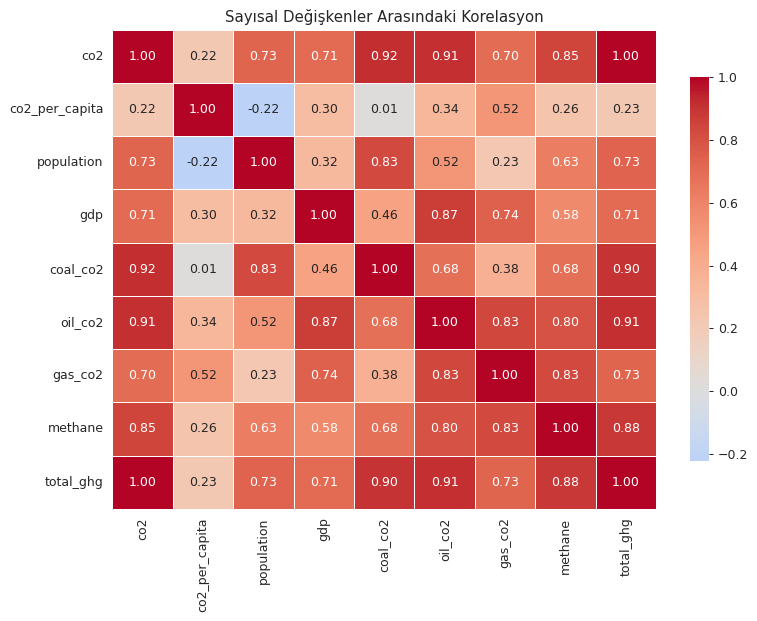

In [12]:
plt.figure(figsize=(9, 7))
sns.heatmap(korelasyon, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Sayısal Değişkenler Arasındaki Korelasyon")
plt.tight_layout()
plt.show()

**Yorum:** Renkler güzel anlatıyor — koyu kırmızı = güçlü pozitif. Burada negatif değer yok çünkü tüm değişkenler doğal olarak birbirine bağlı. En güçlü ilişki: `co2` ↔ `total_ghg` (~0.99). Kişi başı CO2 ise toplam CO2 ile beklenenden daha az ilişkili çünkü nüfus farkı tabloyu değiştiriyor.

## 5. Bulgular ve İçgörüler

Çalışmamın özet sonuçları şunlar:

1. **Emisyon eşitsizliği büyük.** Dünya emisyonunun büyük kısmından sadece birkaç ülke sorumlu. Çin tek başına global toplamın yaklaşık üçte birini üretiyor.

2. **"Toplam" ve "kişi başı" iki ayrı hikaye anlatıyor.** Toplamda 3. olan Hindistan, kişi başında çok düşük (2 ton). Küçük petrol zengini ülkeler ise kişi başı sıralamasının zirvesinde.

3. **Trendler değişiyor.** ABD ve AB ülkeleri 2007 sonrasında ciddi düşüş gösteriyor. Hindistan'ın yükselişi şu an en hızlı.

4. **Ekonomi ↔ emisyon ilişkisi güçlü ama tek değil.** Enerji karışımı (kömür, nükleer, yenilenebilir) belirleyici. Aynı GSYİH'lı ülkelerin emisyonları çok farklı olabiliyor.

5. **Kömür hala büyük pay sahibi.** Veride kömür emisyonları toplam CO2'nin yaklaşık %40'ı civarında.

## 6. Sınırlılıklar ve Gelecek Çalışmalar

- Sadece 30 büyük ülkeyi analiz ettim, küçük ada devletleri vs. dahil değil.
- Üretim bazlı emisyona baktım. Tüketim bazlı emisyon farklı sonuçlar verebilir.
- Sektör bazlı ayrım (ulaşım, enerji, sanayi) yapmadım.
- Sıcaklık değişikliği ile direkt ilişki kurmadım, ileride eklenebilir.